# 01 - Exploration des Donnees
Classification de radiographies thoraciques : NORMAL vs PNEUMONIA

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from collections import Counter

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

IMG_SIZE = 224
BATCH_SIZE = 32

# Verifier que les dossiers existent
print(f"Train: {TRAIN_DIR.exists()}")
print(f"Val: {VAL_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Train: True
Val: True
Test: True


## 1. Comptage des images par classe

In [3]:
def count_images(data_dir):
    counts = {}
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_dir / class_name
        counts[class_name] = len(list(class_dir.glob('*')))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("=== Repartition des donnees ===")
print(f"Train: {train_counts} (Total: {sum(train_counts.values())})")
print(f"Val:   {val_counts} (Total: {sum(val_counts.values())})")
print(f"Test:  {test_counts} (Total: {sum(test_counts.values())})")

=== Repartition des donnees ===
Train: {'NORMAL': 1341, 'PNEUMONIA': 3875} (Total: 5216)
Val:   {'NORMAL': 8, 'PNEUMONIA': 8} (Total: 16)
Test:  {'NORMAL': 234, 'PNEUMONIA': 390} (Total: 624)


C:\Users\User\AppData\Local\Temp\ipykernel_23728\323385067.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


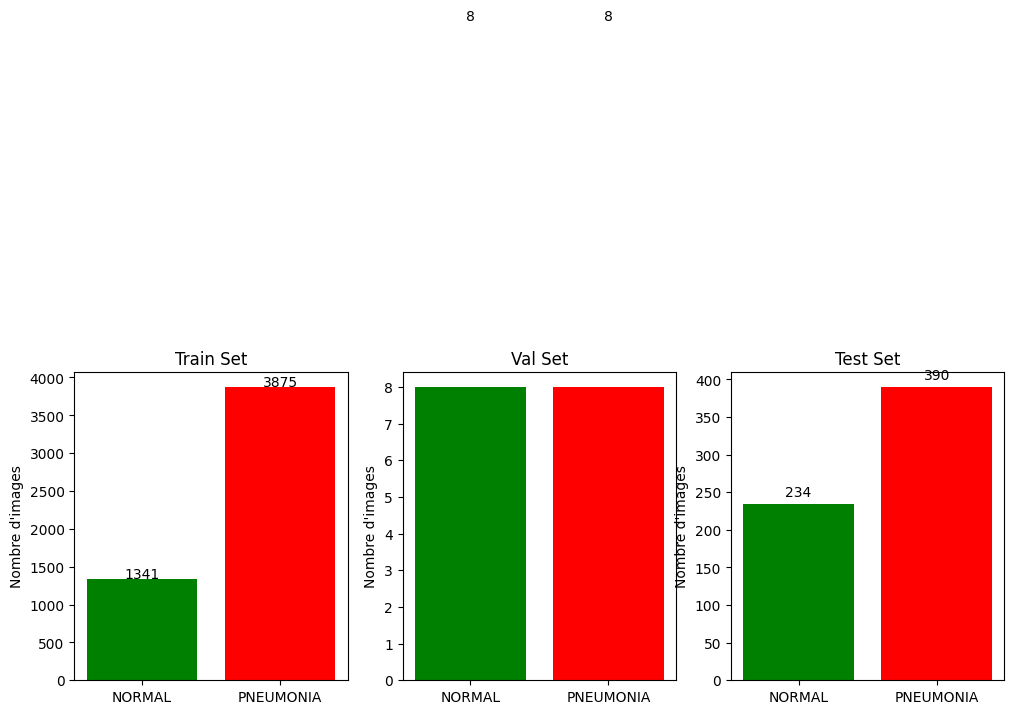

In [4]:
# Visualisation de la repartition
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]):
    ax.bar(counts.keys(), counts.values(), color=['green', 'red'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Nombre d\'images')
    for i, v in enumerate(counts.values()):
        ax.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

## 2. Transforms et DataLoaders

In [5]:
# Transforms pour le train (avec augmentation legere)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # Convertir en 3 canaux
    transforms.RandomRotation(10),  # Rotation legere
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transforms pour val/test (pas d'augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
# Charger les datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Mapping: {train_dataset.class_to_idx}")
print(f"\nTrain: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Classes: ['NORMAL', 'PNEUMONIA']
Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Train: 5216 images
Val: 16 images
Test: 624 images


In [7]:
# Creer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches train: {len(train_loader)}")
print(f"Batches val: {len(val_loader)}")
print(f"Batches test: {len(test_loader)}")

Batches train: 163
Batches val: 1
Batches test: 20


## 3. Visualisation d'un batch

Exemples du Train Set:


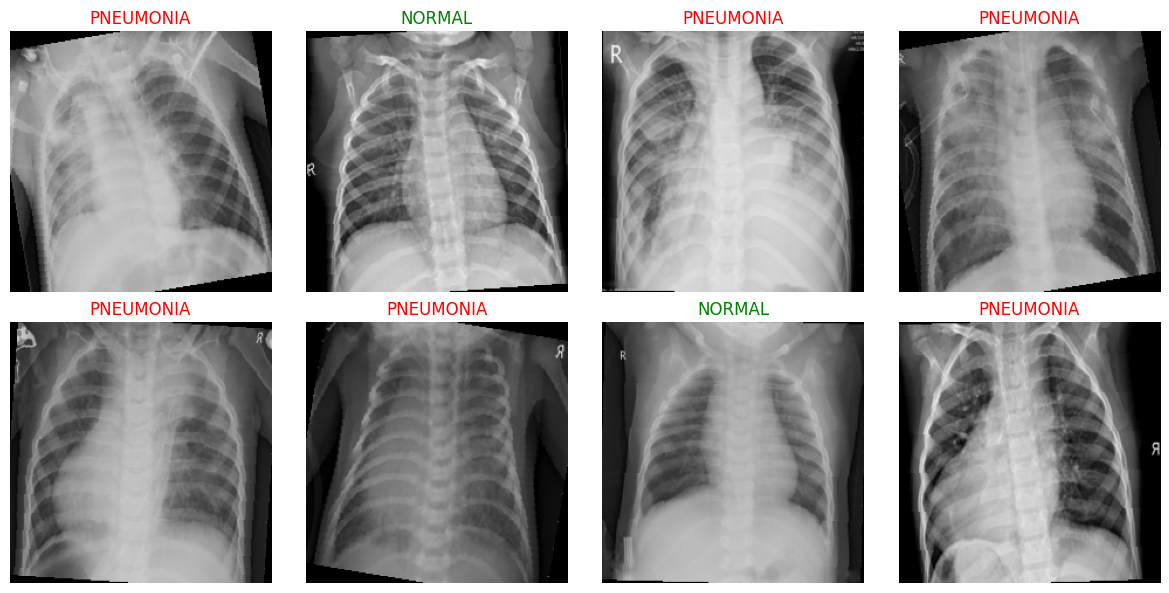

In [8]:
def denormalize(tensor):
    """Denormalise une image pour l'affichage"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def show_batch(dataloader, num_images=8):
    """Affiche un batch d'images"""
    images, labels = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    class_names = ['NORMAL', 'PNEUMONIA']
    
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = denormalize(images[i])
            img = img.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            
            ax.imshow(img)
            ax.set_title(class_names[labels[i]], color='green' if labels[i] == 0 else 'red')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Exemples du Train Set:")
show_batch(train_loader)

## 4. Verification de la forme des donnees

In [9]:
# Verifier la forme d'un batch
images, labels = next(iter(train_loader))
print(f"Shape images: {images.shape}")  # [batch, channels, height, width]
print(f"Shape labels: {labels.shape}")
print(f"Min/Max pixel values: {images.min():.3f} / {images.max():.3f}")

Shape images: torch.Size([32, 3, 224, 224])
Shape labels: torch.Size([32])
Min/Max pixel values: -2.118 / 2.623


## 5. Calcul du poids des classes (pour gerer le desequilibre)

In [10]:
# Calculer les poids pour la loss function
total_train = sum(train_counts.values())
weight_normal = total_train / (2 * train_counts['NORMAL'])
weight_pneumonia = total_train / (2 * train_counts['PNEUMONIA'])

class_weights = torch.tensor([weight_normal, weight_pneumonia])
print(f"Poids des classes: {class_weights}")
print(f"  NORMAL: {weight_normal:.3f}")
print(f"  PNEUMONIA: {weight_pneumonia:.3f}")

Poids des classes: tensor([1.9448, 0.6730])
  NORMAL: 1.945
  PNEUMONIA: 0.673


## Resume

- **Dataset charge** avec transforms (resize 224x224, normalisation ImageNet)
- **Augmentation** sur train: rotation, flip horizontal
- **Desequilibre**: ~3x plus de PNEUMONIA - poids calcules pour la loss
- **Prochain notebook**: Construction et entrainement du CNN